# Семинар 6. RAG and agents

## Введение

В этом ноутбуке мы рассмотрим современные подходы к построению систем класса **Retrieval-Augmented Generation (RAG)** - архитектур, в которых большая языковая модель отвечает на вопрос не только за счёт параметрической памяти, но и с опорой на внешние документы. Такой подход особенно важен в тех случаях, когда необходимо работать с обновляемыми знаниями, узкоспециализированными источниками или длинными коллекциями текстов, которые не были напрямую заучены моделью во время обучения.

С практической точки зрения RAG-система обычно состоит из двух основных частей:
- **retrieval**, то есть поиск фрагментов текста, которые потенциально содержат ответ на запрос.
- **generation**, то есть генерация итогового ответа языковой моделью на основе вопроса и найденного контекста.

> Качество всей системы зависит не только от самой LLM, но и от того, насколько хорошо организован поиск: если в контекст попадают нерелевантные документы, даже сильная модель может дать неточный или неполный ответ.

Поэтому в этом ноутбуке мы будем рассматривать RAG не только как "поиск плюс генерацию", но и как полноценный многоэтапный пайплайн, который можно анализировать, оценивать и улучшать.

Мы начнём с базового dense RAG, затем перейдем к более сложным вариантам retrieval: посмотрим, как работает **hybrid retrieval**, объединяющий плотный и разреженный поиск, и разберем, как оценивать retriever с помощью типичных **IR-метрик ранжирования** - таких как Precision@k, Recall@k, MRR, MAP и nDCG. Это позволит отдельно оценить качество поиска, не смешивая его с качеством генерации.

Отдельное внимание будет уделено **graph RAG**. В ряде задач ответ нельзя получить из одного изолированного фрагмента текста: нужно объединить несколько связанных источников, пройти по цепочке фактов или учесть структуру связей между сущностями и документами.

В таких случаях полезно рассматривать коллекцию данных не просто как набор независимых чанков, а как граф, в котором вершины и рёбра отражают смысловые или фактологические связи. Мы рассмотрим, как графовые представления помогают в multi-hop retrieval и почему такие подходы становятся важным направлением развития RAG.

После этого мы расширим взгляд на RAG еще дальше и посмотрим на **агентные сценарии**. В классическом пайплайне retrieval обычно выполняется один раз по запросу пользователя, но в более сложных задачах системе может понадобиться несколько шагов поиска, уточнение промежуточной гипотезы, повторное обращение к базе знаний или выбор между несколькими инструментами. Для этого используются агентные фреймворки. В ноутбуке мы сравним два подхода - **smolagents** и **LangGraph** - и увидим, как они позволяют строить многошаговые RAG-процессы.

Таким образом, цель этого ноутбука - не просто собрать один рабочий пример RAG, а последовательно показать, как развивается современная retrieval-архитектура: от базового dense retrieval к hybrid retrieval, graph-based retrieval и агентным стратегиям. По ходу работы мы будем не только запускать код, но и анализировать, какие компоненты влияют на итоговое качество системы и почему.

А если кратко, то в этом ноутбуке мы:

1. повторим базовую идею RAG и построим классический retrieval + generation пайплайн;
2. разберем, как оценивать retrieval отдельно от генерации с помощью метрик информационного поиска;
3. покажем, как работает **hybrid retrieval**, объединяющий dense- и sparse-поиск;
4. рассмотрим **graph RAG** как подход к задачам, где важны связи между документами и многошаговый поиск;
5. сравним агентные подходы к RAG на примере **smolagents** и **LangGraph**.

### Основные компоненты ноутбука

| Аббревиатура / термин | Расшифровка                                                 | Роль в ноутбуке                                                                                                                   |
| --------------------- | ----------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| **RAG**               | **Retrieval-Augmented Generation**                          | Общая архитектура, в которой ответ строится не только за счёт параметров LLM, но и с опорой на найденные документы.               |
| **HotpotQA**          | Датасет для **multi-hop question answering**                | Основной учебный набор данных: на нём мы изучаем retrieval, строим qrels и оцениваем качество поиска.                             |
| **Embeddings**        | Векторные представления текста                              | Используются для **dense retrieval**: запрос и документы переводятся в векторы, после чего ищутся семантически близкие фрагменты. |
| **Chroma**            | Open-source **vector store / vector database**              | Хранилище эмбеддингов документов для dense retrieval.                                                                             |
| **BM25**              | Классический **sparse retrieval**-метод                     | Базовый лексический поиск по словам и их статистике в корпусе.                                                                    |
| **Hybrid IR**         | Комбинация **dense** и **sparse retrieval**                 | Показывает, как объединять семантический поиск по эмбеддингам и поиск по ключевым словам в одном пайплайне.                       |
| **IR-метрики**        | Precision@k, Recall@k, MRR, MAP, nDCG                       | Используются для отдельной оценки качества retriever’а, без смешения retrieval и generation.                                      |
| **Graph RAG**         | Retrieval с использованием графовой структуры связей        | Нужен для задач, где ответ опирается на несколько связанных документов или фактов.                                                |
| **LangChain**         | Фреймворк для сборки LLM-приложений                         | Служит как orchestration-слой: связывает retriever, vector store, документы и LLM в единый пайплайн.                              |
| **LangGraph**         | Низкоуровневый runtime для **stateful workflows** и агентов | Используется для явного задания многошагового agentic-RAG-процесса в виде графа состояний и переходов.                            |
| **smolagents**        | Лёгкий агентный фреймворк от Hugging Face                   | Показывает более высокоуровневый подход к agentic RAG через инструменты и многошаговое выполнение.                                |
| **vLLM**              | Inference framework / server для LLM                        | Используется как ускоренный backend для генерации; может работать через OpenAI-compatible API.                                    |
| **LLM**               | **Large Language Model**                                    | Генератор, который получает вопрос и найденный контекст и формирует итоговый ответ.                                               |


### Setting

In [ ]:
!pip install -qU \
  transformers \
  tokenizers \
  accelerate \
  bitsandbytes \
  sentencepiece \
  datasets \
  sentence-transformers \
  chromadb \
  langchain-core \
  langchain-community \
  langchain-huggingface \
  langchain-chroma \
  langchain-classic \
  langchain-text-splitters \
  rank_bm25

In [ ]:
from collections import defaultdict
from itertools import islice # удобно брать первые n элементов из итератора
import math
import numpy as np
import pandas as pd
import networkx as nx # построение и анализ графов
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset

# LangChain / retrieval
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Transformers / generation
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

DEVICE: cuda


### Данные

В этом ноутбуке используется датасет [HotpotQA](https://hotpotqa.github.io/) (distractor split). Он выбран потому, что подходит не только для демонстрации RAG, но и для более глубокого анализа retrieval-компонента.

Каждый пример включает вопрос, правильный ответ, набор контекстных документов и **supporting facts** - фрагменты, которые действительно подтверждают ответ. Благодаря этому датасет удобен для задач **multi-hop retrieval**, где ответ строится на основе нескольких связанных фактов, а не одного изолированного документа.

Кроме того, supporting facts позволяют явно выделять релевантные документы и использовать их для оценки качества поиска с помощью стандартных **IR-метрик ранжирования**. Поэтому на этом датасете можно сравнивать **dense retrieval**, **sparse retrieval**, **hybrid retrieval** и упрощённые варианты **graph-aware retrieval** в рамках одного учебного пайплайна.

## HotpotQA

Поскольку ноутбук рассчитан на запуск в Colab, мы не используем датасет целиком. Вместо этого данные читаются постепенно, в режиме **streaming**, и для работы берётся только ограниченный поднабор примеров.

Это позволяет быстрее запускать ноутбук и не перегружать память:
- одна часть примеров используется для построения учебного графа документов,
- другая - для небольшой evaluation-выборки, на которой можно сравнить качество разных retriever'ов.

При необходимости объем данных можно уменьшить еще сильнее с помощью параметров `GRAPH_BUILD_N` и `EVAL_N`.

In [ ]:
GRAPH_BUILD_N = 3000 # сколько примеров используем для графа
EVAL_N = 150 # сколько пойдет на оценку retrieval

train_stream = load_dataset(
    "hotpotqa/hotpot_qa",
    "distractor",
    split="train",
    streaming=True # вот здесь включается стриминг
)

val_stream = load_dataset(
    "hotpotqa/hotpot_qa",
    "distractor",
    split="validation",
    streaming=True
)

graph_items = list(islice(train_stream, GRAPH_BUILD_N))
eval_items = list(islice(val_stream, EVAL_N))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

In [ ]:
print(f"graph_items: {len(graph_items)}")
print(f"eval_items : {len(eval_items)}")

graph_items: 3000
eval_items : 150


In [ ]:
print(eval_items[0].keys())
print(eval_items[0]["supporting_facts"])
print(eval_items[0]["context"].keys())

dict_keys(['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context'])
{'title': ['Scott Derrickson', 'Ed Wood'], 'sent_id': [0, 0]}
dict_keys(['title', 'sentences'])


In [ ]:
def show_hotpot_example_short(item):
    print(f"Вопрос: {item['question']}")
    print(f"Ответ: {item.get('answer', '<no answer>')}")

    sf_titles = item["supporting_facts"]["title"]
    sf_sent_ids = item["supporting_facts"]["sent_id"]
    ctx_titles = item["context"]["title"]
    ctx_sentences = item["context"]["sentences"]

    print("\nSupport docs:")
    for title in sorted(set(sf_titles)):
        print(f"  • {title}")

    print("\nSupport sentences:")
    for title, sent_id in zip(sf_titles, sf_sent_ids):
        if title in ctx_titles:
            doc_idx = ctx_titles.index(title)
            sents = ctx_sentences[doc_idx]
            sent_text = sents[sent_id] if sent_id < len(sents) else "<sent_id вне диапазона>"
            print(f"\n[{title}]")
            print(f"  {sent_text}")

show_hotpot_example_short(eval_items[0])

Вопрос: Were Scott Derrickson and Ed Wood of the same nationality?
Ответ: yes

Support docs:
  • Ed Wood
  • Scott Derrickson

Support sentences:

[Scott Derrickson]
  Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.

[Ed Wood]
  Edward Davis Wood Jr. (October 10, 1924 – December 10, 1978) was an American filmmaker, actor, writer, producer, and director.


## Подготавливаем корпус документов

Чтобы оценивать качество retrieval, нам нужно привести данные к более стандартному для информационного поиска виду. Для этого мы строим три объекта:

* **corpus** - коллекцию документов, по которым будет выполняться поиск;
* **queries** - набор пользовательских запросов;
* **qrels** - разметку релевантности, то есть указание, какие документы считаются правильными для каждого запроса.

В этом ноутбуке в качестве одного документа мы будем рассматривать один заголовок `title` из HotpotQA. Все предложения, относящиеся к этому заголовку, объединяются в единый текст документа.

Такое представление удобно по нескольким причинам.

- Во-первых, в HotpotQA supporting facts уже привязаны к конкретным заголовкам документов, поэтому релевантность легко определить именно на уровне документа.
- Во-вторых, такой формат хорошо подходит для первых экспериментов с retrieval-метриками: мы можем сравнивать, попали ли нужные документы в top-k выдачи.
- В-третьих, это делает структуру данных более простой и понятной: один `title` соответствует одному документу в корпусе.

Под **qrels** здесь мы будем понимать словарь вида:

`query_id -> множество релевантных документов`

В нашем случае релевантными считаются те документы, чьи заголовки входят в `supporting_facts["title"]`. Иначе говоря, если HotpotQA помечает некоторый документ как опорный для ответа, мы считаем его правильным документом для retrieval.

В более сложных RAG-системах можно использовать более детальную схему, например:

`документ -> чанки -> reranking`

Но для нашего учебного ноутбука удобнее начать с более простого уровня: **один title = один документ**.

In [ ]:
title2text = {}
queries = {}
qrels = {} # query_id -> множество релевантных заголовков документов

for item in eval_items:
    qid = item["id"]

    # текст запроса
    queries[qid] = item["question"]

    # релевантные документы для данного запроса.
    # берем их из supporting facts.
    qrels[qid] = set(item["supporting_facts"]["title"])

    # собираем корпус документов:
    # каждому title сопоставляем полный текст, составленный из предложений
    for title, sentences in zip(item["context"]["title"], item["context"]["sentences"]):
        text = " ".join(sentences).strip()
        if not text:
            continue

        # один и тот же title может встретиться в нескольких примерах.
        # если это произошло, оставим более длинную версию текста.
        if title not in title2text or len(text) > len(title2text[title]):
            title2text[title] = text

# преобразуем корпус в формат Document, с которым удобно работать в LangChain
docs = [
    Document(page_content=text, metadata={"title": title})
    for title, text in title2text.items()
]

print("Уникальных документов в корпусе:", len(docs))
print("Уникальных запросов:", len(queries))

print("\nПример документа:")
print("Title:", docs[0].metadata["title"])
print("Text:", docs[0].page_content[:500] + " ...")

Уникальных документов в корпусе: 1491
Уникальных запросов: 150

Пример документа:
Title: Ed Wood (film)
Text: Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.  The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.  Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast. ...


## Про чанки

В реальных RAG-системах документы часто оказываются слишком длинными, чтобы работать с ними целиком. Поэтому перед индексацией текст обычно разбивают на более короткие фрагменты - **чанки**.

Это делают по двум основным причинам.

**1. Улучшение retrieval**

Если весь длинный документ представить одним embedding, нужный фрагмент может потеряться внутри общего содержания. Когда текст разбит на чанки, retriever с большей вероятностью находит именно тот кусок, где содержится ответ.

**2. Ограничение контекста модели**

Даже если полезный документ найден, целиком передавать его в LLM может быть слишком дорого или невозможно из-за ограничения на длину входа. Короткие чанки проще передавать в модель.

**Что важно при разбиении?**

Обычно при chunking учитывают два параметра:

* **`chunk_size`** - максимальный размер одного чанка;
* **`chunk_overlap`** - перекрытие между соседними чанками.

Перекрытие нужно для того, чтобы важная мысль не потерялась на границе между двумя соседними фрагментами.

Обычно пайплайн устроен так:

> **документ -> чанки -> embeddings -> retrieval**

Сначала длинный текст разбивается на части, затем для каждой части строится embedding, после чего поиск выполняется уже не по целым документам, а по отдельным чанкам.


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

sample_text = """
Alan Turing was a British mathematician, logician, cryptanalyst, and computer scientist.
He played a major role in the development of theoretical computer science.
Turing is widely considered one of the fathers of modern computing.

During World War II, he worked at Bletchley Park, where he contributed to cryptanalysis.
In particular, he was involved in efforts related to the German Enigma cipher.

His ideas about computation later influenced the development of artificial intelligence.
The well-known Turing Test was proposed as a way to discuss machine intelligence.
""".strip()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=140, # максимальный размер чанка
    chunk_overlap=30 # перекрытие между соседними чанками
)

chunks = splitter.split_text(sample_text)

print(f"Количество чанков: {len(chunks)}\n")
for i, chunk in enumerate(chunks, 1):
    print(f"--- Чанк {i} ---")
    print(chunk)
    print()

Количество чанков: 7

--- Чанк 1 ---
Alan Turing was a British mathematician, logician, cryptanalyst, and computer scientist.

--- Чанк 2 ---
He played a major role in the development of theoretical computer science.

--- Чанк 3 ---
Turing is widely considered one of the fathers of modern computing.

--- Чанк 4 ---
During World War II, he worked at Bletchley Park, where he contributed to cryptanalysis.

--- Чанк 5 ---
In particular, he was involved in efforts related to the German Enigma cipher.

--- Чанк 6 ---
His ideas about computation later influenced the development of artificial intelligence.

--- Чанк 7 ---
The well-known Turing Test was proposed as a way to discuss machine intelligence.



В этом ноутбуке дальше мы в основном работаем с документами на уровне `title`, потому что для HotpotQA это удобно с точки зрения оценки retrieval. Однако сам принцип chunking важно понимать, поскольку в более реалистичных RAG-системах он используется почти всегда.

## LangChain как рабочая среда для RAG

<img src="https://miro.medium.com/v2/resize:fit:940/1*44fD_VXcqw2kDWublQLONw.jpeg" alt="LangChain vs LLM Stack" width="400">

[LangChain](https://github.com/langchain-ai/langchain) - это Python-фреймворк для создания **приложений на базе больших языковых моделей (LLM)**, таких как LLaMA, GPT, DeepSeek и другие. Он упрощает построение цепочек (`chains`), где LLM взаимодействует с внешними источниками знаний, выполняет пошаговые вычисления, вызывает инструменты и возвращает результат в едином пайплайне.

С его помощью можно работать с документами в едином формате, подключать dense- и sparse-retrieval, объединять несколько retriever'ов в hybrid retrieval и затем использовать найденный контекст в RAG-пайплайне.

Именно поэтому перед началом практической части полезно отдельно зафиксировать, что LangChain в этом ноутбуке играет роль **инфраструктурного слоя**, который связывает данные, retrieval и генерацию в единую систему.

**Другие фреймворки**

Помимо LangChain, для задач RAG и агентных систем используют и другие фреймворки.

| Фреймворк           | Краткая идея                                                                                                                                                             |
| ------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **LlamaIndex**      | Часто используется как data framework для приложений поверх внешних данных и retrieval-сценариев.           |
| **Haystack**        | Сильный акцент на поисковые пайплайны и production-oriented retrieval; в экосистеме есть интеграции с BM25, embedding retrieval и hybrid retrieval через OpenSearch. |
| **Semantic Kernel** | Open-source SDK от Microsoft для интеграции моделей и построения AI- и agent-based приложений в C#, Python и Java.                     |
| **smolagents**      | Легкая библиотека Hugging Face для agentic-сценариев; к ней мы отдельно вернемся во второй части ноутбука.         |

In [ ]:
# Document - базовый объект документа в LangChain.
# В нём обычно хранятся:
# 1) page_content — сам текст,
# 2) metadata — дополнительная информация о документе.
from langchain_core.documents import Document

# HuggingFaceEmbeddings превращает текст в плотные векторы (embeddings).
# Эти векторы затем используются для поиска семантически похожих документов.
from langchain_huggingface import HuggingFaceEmbeddings

# Chroma — векторное хранилище.
# В него мы будем сохранять embeddings документов и выполнять dense retrieval.
from langchain_chroma import Chroma

# BM25Retriever реализует классический sparse-поиск:
# документы ранжируются по совпадениям слов и их статистике в корпусе.
from langchain_community.retrievers import BM25Retriever

# В LangChain v1 старые retriever-модули вынесены в langchain-classic.
# EnsembleRetriever нужен для hybrid retrieval:
# он объединяет результаты нескольких retriever'ов.
from langchain_classic.retrievers import EnsembleRetriever

### Создание векторной базы

`Chroma` - это интерфейс к векторной базе данных ChromaDB, встроенный в LangChain. Он позволяет:

* сохранять текстовые документы как **векторные представления** (эмбеддинги),
* осуществлять **поиск по векторной близости** (косинусное сходство и др.),
* использовать найденные документы в Retrieval-Augmented Generation (RAG).

In [ ]:
# Chroma - векторное хранилище.
# В него мы будем сохранять embeddings документов и выполнять dense retrieval.
from langchain_chroma import Chroma



Альтернативы `Chroma` в LangChain

| База              | Особенности                                     |
| ----------------- | ----------------------------------------------- |
| **FAISS**         | Очень быстрый и простой, но без метаданных      |
| **Weaviate**      | Облачная/локальная, продвинутая фильтрация      |
| **Pinecone**      | SaaS, высокая масштабируемость                  |
| **Qdrant**        | Open-source, фильтрация, кластеризация          |
| **Milvus**        | Мощная и масштабируемая, но сложнее в настройке |
| **Elasticsearch** | Поддержка вектора + ключевых слов               |


## Dense retriever

Сначала строим стандартный **dense retriever**:

- для каждого документа вычисляется эмбеддинг;
- эмбеддинги индексируются в `Chroma`;
- по запросу возвращаются наиболее близкие документы.

В качестве модели эмбеддингов используется `sentence-transformers/all-mpnet-base-v2`, которая часто применяется как базовый dense retrieval baseline.


In [ ]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2",
    model_kwargs={"device": DEVICE},
)

vectordb = Chroma.from_documents(
    documents=docs,
    embedding=embeddings,
    persist_directory="chroma_hotpot_demo"
)

dense_retriever = vectordb.as_retriever(search_kwargs={"k": 10})

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Sparse retriever (BM25) и hybrid retriever

Помимо dense retrieval полезно рассмотреть и **лексический поиск**. Для этого добавляется retriever на основе **BM25**.

BM25 особенно полезен в ситуациях, когда:

- в вопросе присутствуют редкие имена, даты, аббревиатуры;
- важны точные совпадения токенов;
- семантический retriever улавливает общий смысл, но пропускает ключевое слово.

После этого строится **hybrid retriever** на основе `EnsembleRetriever`, который объединяет dense и sparse поиск через **rank fusion**.

Такой подход позволяет совместить преимущества двух стратегий retrieval.


> `EnsembleRetriever` в LangChain объединяет результаты нескольких поисковиков с помощью **weighted Reciprocal Rank Fusion**: он берет ранжированные списки от каждого retriever'а и собирает из них один общий список. Параметр `weights` задает, насколько сильно мы доверяем каждому retriever'у при этом объединении.


In [ ]:
bm25_retriever = BM25Retriever.from_documents(docs)
bm25_retriever.k = 10

# EnsembleRetriever объединяет результаты нескольких retriever'ов.
# Здесь мы комбинируем:
# 1) BM25 — поиск по словам,
# 2) dense retriever — поиск по смысловой близости.

hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.4, 0.6],
)

# Параметр weights задаёт вклад каждого retriever'а в итоговое ранжирование.
# В данном случае dense retriever получает немного больший вес, чем BM25.
# `0.4` — вклад `bm25_retriever`,
# `0.6` — вклад `dense_retriever`.

## Метрики retrieval

Оценка retrieval только через итоговый ответ генератора недостаточна, потому что в этом случае трудно отделить ошибки поиска от ошибок генерации. Поэтому retriever анализируется как отдельная **information retrieval**-подсистема.

Обозначения:

- `relevant` - множество релевантных документов для вопроса;
- `ranking[:k]` - top-k документов, возвращенных retriever'ом.

Далее вычисляются стандартные IR-метрики:

- **Precision@k**  

Показывает, какая доля документов в top-k является релевантной.

- **Recall@k**  

Показывает, какую долю всех релевантных документов удалось найти среди top-k.

- **MRR@k**  

Оценивает, насколько рано в ранжированном списке появляется первый релевантный документ.

- **AP / MAP@k**  

Учитывает не только наличие релевантных документов, но и их позиции в выдаче.  `MAP` - это среднее значение `AP` по всем вопросам.

- **nDCG@k**  

Оценивает качество ранжирования с учетом позиций документов и особенно полезна в задачах сравнения retrieval-систем.


In [ ]:
def unique_titles_from_docs(retrieved_docs, k=10):
    titles = []
    seen = set()
    for doc in retrieved_docs:
        title = doc.metadata.get("title")
        if title is None or title in seen:
            continue
        titles.append(title)
        seen.add(title)
        if len(titles) >= k:
            break
    return titles

def retrieve_titles(retriever, query, k=10):
    docs = retriever.invoke(query)
    return unique_titles_from_docs(docs, k=k)

def precision_at_k(relevant, ranking, k):
    topk = ranking[:k]
    if k == 0:
        return 0.0
    hits = sum(1 for doc_id in topk if doc_id in relevant)
    return hits / k

def recall_at_k(relevant, ranking, k):
    if len(relevant) == 0:
        return 0.0
    topk = ranking[:k]
    hits = sum(1 for doc_id in topk if doc_id in relevant)
    return hits / len(relevant)

def reciprocal_rank_at_k(relevant, ranking, k):
    for rank, doc_id in enumerate(ranking[:k], start=1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0

def average_precision_at_k(relevant, ranking, k):
    if len(relevant) == 0:
        return 0.0
    score = 0.0
    hits = 0
    for rank, doc_id in enumerate(ranking[:k], start=1):
        if doc_id in relevant:
            hits += 1
            score += hits / rank
    return score / len(relevant)

def dcg_at_k(relevant, ranking, k):
    score = 0.0
    for rank, doc_id in enumerate(ranking[:k], start=1):
        rel = 1.0 if doc_id in relevant else 0.0
        score += rel / math.log2(rank + 1)
    return score

def ndcg_at_k(relevant, ranking, k):
    ideal_ranking = list(relevant)
    ideal_dcg = dcg_at_k(relevant, ideal_ranking, min(k, len(relevant)))
    if ideal_dcg == 0:
        return 0.0
    return dcg_at_k(relevant, ranking, k) / ideal_dcg

def evaluate_rankings(rankings_by_qid, qrels, ks=(1, 2, 5, 10)):
    rows = []
    for qid, ranking in rankings_by_qid.items():
        relevant = qrels[qid]
        row = {"qid": qid}
        for k in ks:
            row[f"P@{k}"] = precision_at_k(relevant, ranking, k)
            row[f"R@{k}"] = recall_at_k(relevant, ranking, k)
            row[f"MRR@{k}"] = reciprocal_rank_at_k(relevant, ranking, k)
            row[f"MAP@{k}"] = average_precision_at_k(relevant, ranking, k)
            row[f"nDCG@{k}"] = ndcg_at_k(relevant, ranking, k)
        rows.append(row)
    return pd.DataFrame(rows).mean(numeric_only=True)

def build_rankings(retriever, queries, k=10, desc="retrieving"):
    rankings = {}
    for qid, query in tqdm(queries.items(), total=len(queries), desc=desc):
        rankings[qid] = retrieve_titles(retriever, query, k=k)
    return rankings

In [ ]:
dense_rankings = build_rankings(dense_retriever, queries, k=10, desc="Dense")
bm25_rankings = build_rankings(bm25_retriever, queries, k=10, desc="BM25")
hybrid_rankings = build_rankings(hybrid_retriever, queries, k=10, desc="Hybrid")

results = pd.DataFrame([
    {"method": "Dense", **evaluate_rankings(dense_rankings, qrels).to_dict()},
    {"method": "BM25", **evaluate_rankings(bm25_rankings, qrels).to_dict()},
    {"method": "Hybrid", **evaluate_rankings(hybrid_rankings, qrels).to_dict()},
])

results = results.round(4)
results

Dense:   0%|          | 0/150 [00:00<?, ?it/s]

BM25:   0%|          | 0/150 [00:00<?, ?it/s]

Hybrid:   0%|          | 0/150 [00:00<?, ?it/s]

,method,P@1,R@1,MRR@1,MAP@1,nDCG@1,P@2,R@2,MRR@2,MAP@2,...,P@5,R@5,MRR@5,MAP@5,nDCG@5,P@10,R@10,MRR@10,MAP@10,nDCG@10
0,Dense,0.8200,0.4100,0.8200,0.4100,0.8200,0.6233,0.6233,0.8767,0.5950,...,0.3080,0.7700,0.8952,0.6669,0.7492,0.1780,0.8900,0.8952,0.6992,0.7969
1,BM25,0.6667,0.3333,0.6667,0.3333,0.6667,0.4500,0.4500,0.7233,0.4217,...,0.2427,0.6067,0.7569,0.4866,0.5833,0.1547,0.7733,0.7660,0.5261,0.6492
2,Hybrid,0.7667,0.3833,0.7667,0.3833,0.7667,0.5500,0.5500,0.8300,0.5183,...,0.3027,0.7567,0.8599,0.6193,0.7145,0.1773,0.8867,0.8607,0.6541,0.7663



При сравнении retriever'ов обычно наблюдаются следующие эффекты:

- **BM25** лучше обрабатывает точные совпадения имен, дат и редких токенов;
- **dense retrieval** лучше работает с перефразировками и семантически близкими формулировками;
- **hybrid retrieval** часто оказывается устойчивее, поскольку объединяет оба сигнала.

Особенно важны следующие метрики:

- `R@2` и `R@5` - показывают, удается ли найти несколько опорных документов, что важно для multi-hop QA;
- `MRR@10` - показывает, насколько высоко расположен первый релевантный документ;
- `nDCG@10` - дает более полную оценку качества ранжирования, чем метрики, учитывающие только факт попадания документа в top-k.

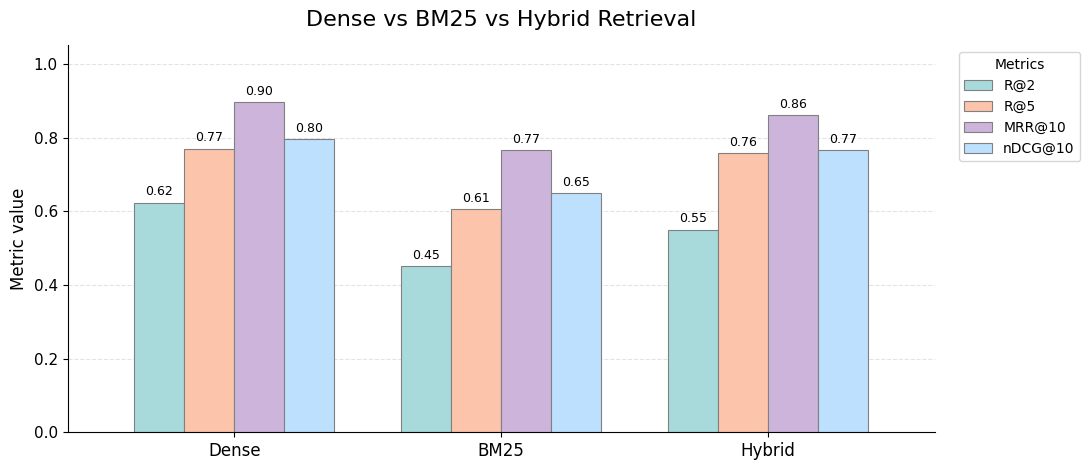

In [ ]:
# тут много строчек - чисто для красоты
# только она способна спасти наш мир

plot_cols = ["R@2", "R@5", "MRR@10", "nDCG@10"]
pastel_colors = ["#A8DADC", "#FBC4AB", "#CDB4DB", "#BDE0FE"]

fig, ax = plt.subplots(figsize=(11, 4.8))

results_plot = results.set_index("method")[plot_cols]
results_plot.plot(
    kind="bar",
    ax=ax,
    color=pastel_colors,
    edgecolor="gray",
    linewidth=0.8,
    width=0.75
)

ax.set_title("Dense vs BM25 vs Hybrid Retrieval", fontsize=16, pad=14)
ax.set_ylabel("Metric value", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=0, labelsize=12)
ax.tick_params(axis="y", labelsize=11)

ax.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Легкий graph-aware retrieval

Следующий шаг - построение **графа документов**.

Идея состоит в следующем:

- в HotpotQA для train-примеров известны supporting documents;
- если два документа часто встречаются вместе как supporting facts, между ними можно добавить ребро;
- при поиске сначала выбираются seed-документы обычным retriever'ом, после чего набор кандидатов расширяется их соседями по графу.

Этот вариант является **облегченной graph-aware retrieval схемой**. Он отличается от полного Microsoft GraphRAG, потому что здесь:

- не выполняется LLM-экстракция сущностей;
- не строятся communities;
- не используются режимы `local`, `global` и `DRIFT search`.

Тем не менее такая постановка хорошо показывает саму идею: связи между документами можно использовать как дополнительный источник сигналов для retrieval.


### Microsoft GraphRAG?

[Microsoft GraphRAG](https://microsoft.github.io/graphrag/) - одна из наиболее известных graph-based RAG-схем. GraphRAG - это подход, в котором из неструктурированного текста с помощью LLM строится граф знаний, затем в нём выделяются сообщества связанных узлов, создаются их краткие описания, и уже эти структуры используются для retrieval и генерации ответа.

В официальной реализации GraphRAG ([статья](https://arxiv.org/pdf/2404.16130)) используются более сложные этапы, чем в нашем ноутбуке. Там могут применяться LLM-экстракция сущностей и связей, построение community hierarchy, а также разные режимы поиска, например local, global и DRIFT search.

Минимальный пример команд, которые можно использовать для знакомства с библиотекой:

```bash
pip install graphrag
python -m graphrag.index --init --root ./my_graphrag_project
python -m graphrag.index --root ./my_graphrag_project
python -m graphrag.query --root ./my_graphrag_project --method local "Your question"
```


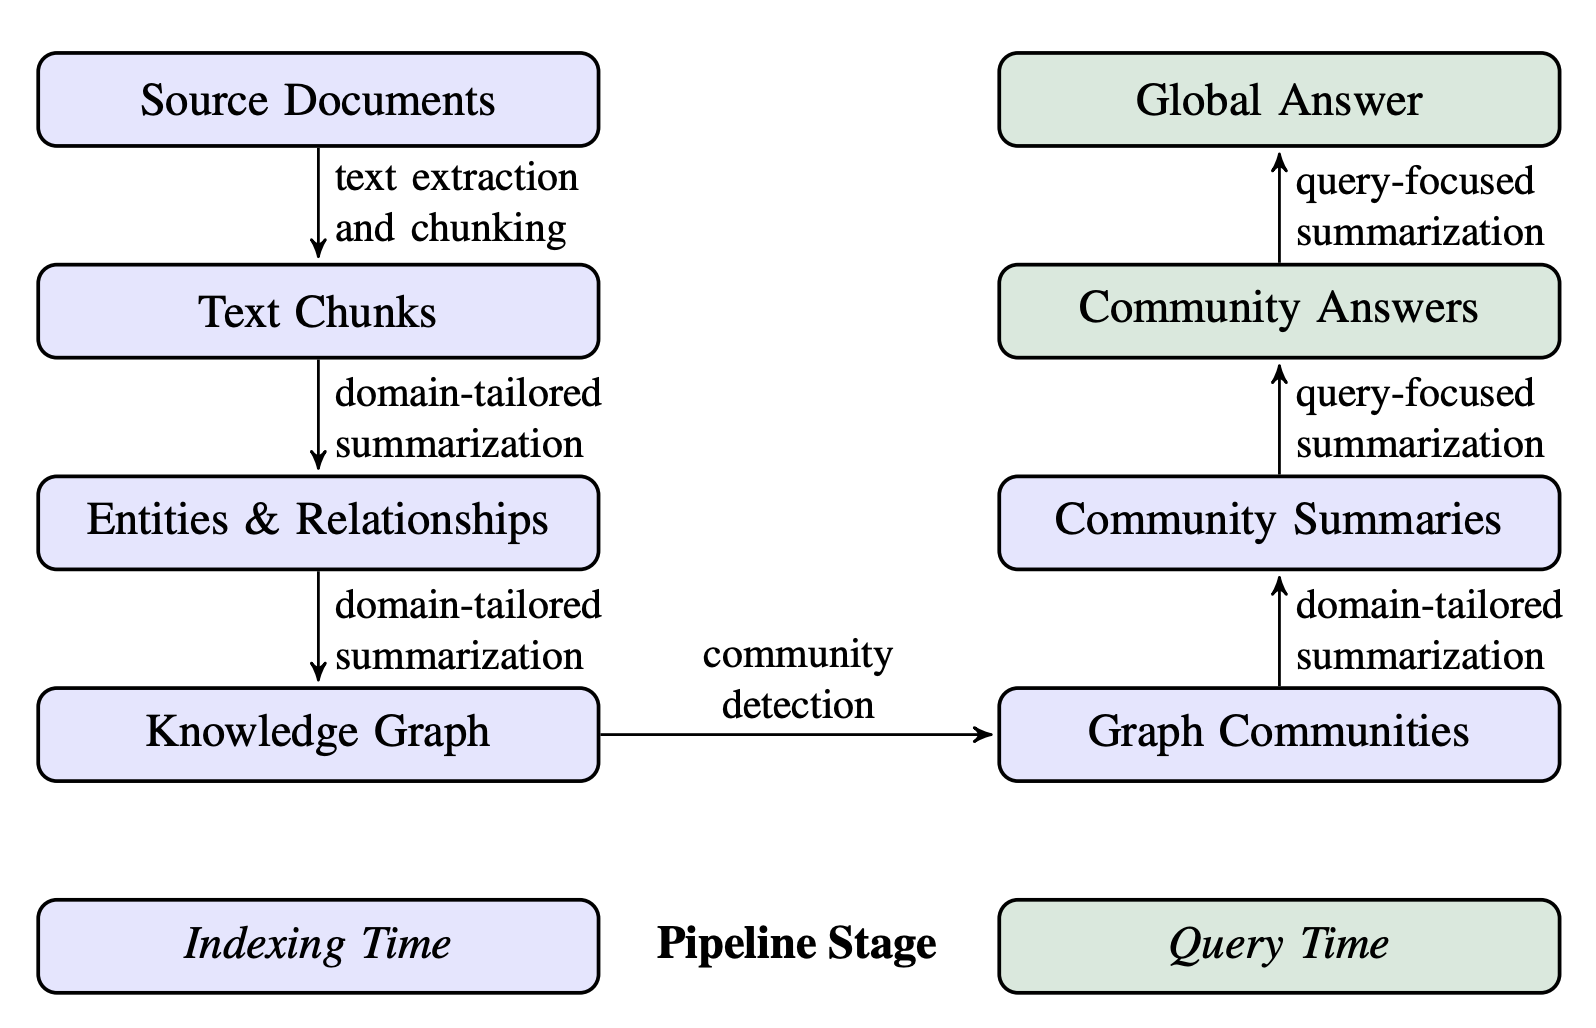

Ниже мы используем только облегченную graph-aware retrieval схему, но полезно понимать, что в более полном виде эта идея реализована в Microsoft GraphRAG. В нём из исходных документов строится граф знаний: текст разбивается на чанки, из них извлекаются сущности и связи, затем формируются графовые сообщества и их summary-представления. Уже на этапе запроса система использует эти структуры для построения более глобального и связного ответа.

### Поехали дальше

In [ ]:
# cоздаём пустой неориентированный граф
# узлы графа - это документы (точнее, их title),
# а ребро между двумя узлами означает, что эти документы
# встречались вместе как supporting documents в одном и том же примере
G = nx.Graph()

for item in tqdm(graph_items, desc="Building support graph"):
    # берём список supporting-документов для текущего примера
    # dict.fromkeys() используется как простой способ убрать повторы,
    # но при этом сохранить исходный порядок title
    titles = list(dict.fromkeys(item["supporting_facts"]["title"]))

    # если supporting document только один,
    # то связи между документами здесь построить нельзя
    if len(titles) < 2:
        continue

    # добавляем все документы как узлы графа
    # в NetworkX узлами могут быть, например, строки,
    # поэтому title удобно использовать как идентификатор узла
    for title in titles:
        G.add_node(title)

    # теперь соединяем все пары документов внутри одного примера
    # если два документа встретились вместе,
    # считаем это сигналом связи между ними
    for i in range(len(titles)):
        for j in range(i + 1, len(titles)):
            a, b = titles[i], titles[j]

            # если такое ребро уже существует,
            # увеличиваем его вес на 1
            # вес здесь показывает,
            # сколько раз эта пара документов встречалась вместе
            if G.has_edge(a, b):
                G[a][b]["weight"] += 1
            else:
                # если ребра ещё не было, создаём его с начальным весом 1
                G.add_edge(a, b, weight=1)

print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")

Building support graph:   0%|          | 0/3000 [00:00<?, ?it/s]

Nodes: 5,805
Edges: 2,981


## Предвычислим эмбеддинги документов для graph-aware reranking

После графового расширения формируется набор кандидатов, который необходимо отсортировать.

Для этого используется простая функция вида:

> **score = semantic_similarity(query, doc) + graph_bonus**

Здесь граф не заменяет dense retrieval, а выступает как дополнительный сигнал, который усиливает документы, связанные с уже найденными релевантными узлами.


In [ ]:
titles = [doc.metadata["title"] for doc in docs]
texts = [doc.page_content for doc in docs]
title2idx = {title: i for i, title in enumerate(titles)}

doc_embs = np.array(embeddings.embed_documents(texts), dtype=np.float32)
doc_embs /= (np.linalg.norm(doc_embs, axis=1, keepdims=True) + 1e-12)

def encode_query(query):
    q = np.array(embeddings.embed_query(query), dtype=np.float32)
    q /= (np.linalg.norm(q) + 1e-12)
    return q

In [ ]:
def graph_retrieve_titles(
    query,
    seed_retriever=hybrid_retriever,
    seed_k=3,
    neighbor_top=5,
    final_k=10,
    graph_bonus=0.15
):
    # стартуем с обычного retrieval
    seed_titles = retrieve_titles(seed_retriever, query, k=seed_k)

    # расширяем соседями по графу
    candidate_titles = set(seed_titles)
    bonus = defaultdict(float)

    for seed_rank, seed_title in enumerate(seed_titles, start=1):
        if seed_title not in G:
            continue

        neighbors = sorted(
            G[seed_title].items(),
            key=lambda x: x[1].get("weight", 1),
            reverse=True
        )[:neighbor_top]

        if not neighbors:
            continue

        max_w = neighbors[0][1].get("weight", 1)

        for neigh_title, attrs in neighbors:
            candidate_titles.add(neigh_title)
            rel_w = attrs.get("weight", 1) / max_w
            seed_importance = 1.0 / seed_rank
            bonus[neigh_title] = max(bonus[neigh_title], rel_w * seed_importance)

    # rerank кандидатов по dense similarity + graph bonus
    q = encode_query(query)
    scored = []

    for title in candidate_titles:
        idx = title2idx.get(title)
        if idx is None:
            continue
        sim = float(doc_embs[idx] @ q)
        score = sim + graph_bonus * bonus.get(title, 0.0)
        scored.append((title, score))

    scored.sort(key=lambda x: x[1], reverse=True)
    return [title for title, _ in scored[:final_k]]

graph_rankings = {}
for qid, query in tqdm(queries.items(), total=len(queries), desc="Graph-aware"):
    graph_rankings[qid] = graph_retrieve_titles(query)

graph_results = evaluate_rankings(graph_rankings, qrels).to_dict()
graph_row = {"method": "Graph-aware", **graph_results}
results_plus_graph = pd.concat(
    [results, pd.DataFrame([graph_row])],
    ignore_index=True
).round(4)

results_plus_graph

Graph-aware:   0%|          | 0/150 [00:00<?, ?it/s]

,method,P@1,R@1,MRR@1,MAP@1,nDCG@1,P@2,R@2,MRR@2,MAP@2,...,P@5,R@5,MRR@5,MAP@5,nDCG@5,P@10,R@10,MRR@10,MAP@10,nDCG@10
0,Dense,0.8200,0.4100,0.8200,0.4100,0.8200,0.6233,0.6233,0.8767,0.5950,...,0.3080,0.7700,0.8952,0.6669,0.7492,0.1780,0.8900,0.8952,0.6992,0.7969
1,BM25,0.6667,0.3333,0.6667,0.3333,0.6667,0.4500,0.4500,0.7233,0.4217,...,0.2427,0.6067,0.7569,0.4866,0.5833,0.1547,0.7733,0.7660,0.5261,0.6492
2,Hybrid,0.7667,0.3833,0.7667,0.3833,0.7667,0.5500,0.5500,0.8300,0.5183,...,0.3027,0.7567,0.8599,0.6193,0.7145,0.1773,0.8867,0.8607,0.6541,0.7663
3,Graph-aware,0.7867,0.3933,0.7867,0.3933,0.7867,0.5733,0.5733,0.8467,0.5433,...,0.2613,0.6533,0.8644,0.5878,0.6707,0.1307,0.6533,0.8644,0.5878,0.6707


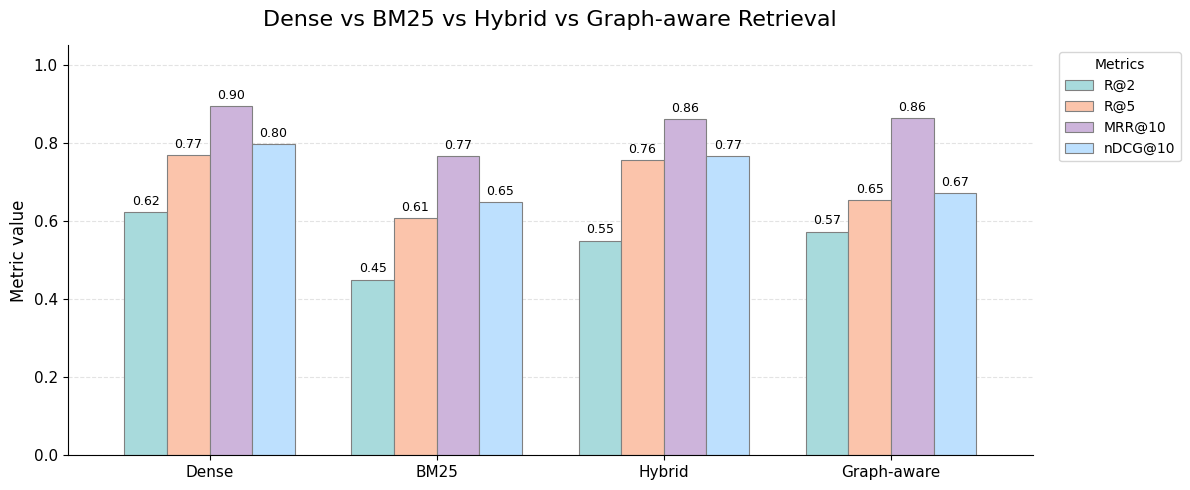

In [ ]:
plot_cols = ["R@2", "R@5", "MRR@10", "nDCG@10"]
fig, ax = plt.subplots(figsize=(12, 5))

results_plot = results_plus_graph.set_index("method")[plot_cols]
results_plot.plot(
    kind="bar",
    ax=ax,
    color=pastel_colors,
    edgecolor="gray",
    linewidth=0.8,
    width=0.75
)

ax.set_title("Dense vs BM25 vs Hybrid vs Graph-aware Retrieval", fontsize=16, pad=14)
ax.set_ylabel("Metric value", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=0, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

ax.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Посмотрим теперь на примеры


In [ ]:
def count_hits(ranking, relevant, k=5):
    return sum(1 for title in ranking[:k] if title in relevant)

interesting = []

for qid in queries:
    rel = qrels[qid]
    d = count_hits(dense_rankings[qid], rel, k=5)
    h = count_hits(hybrid_rankings[qid], rel, k=5)
    g = count_hits(graph_rankings[qid], rel, k=5)

    if g > h or h > d:
        interesting.append((qid, d, h, g))

# ищем интересные вопросы, на которых более сложные retriever'ы
# действительно улучшают retrieval по сравнению с базовым dense-поиском.
# сравниваем число релевантных документов в top-5 выдачи.
interesting[:10]

[('5abf63f15542997ec76fd3ea', 1, 2, 1),
 ('5a80721b554299485f5985ef', 1, 2, 1),
 ('5a7320565542991f9a20c61d', 1, 2, 2),
 ('5a835478554299123d8c20ed', 1, 2, 1),
 ('5ae53b545542990ba0bbb23c', 1, 2, 2),
 ('5ae2b770554299495565db0f', 1, 2, 1),
 ('5a8bb29b554299240d9c2089', 1, 2, 2),
 ('5a89f5815542993b751ca9c5', 1, 2, 1),
 ('5ab69c25554299110f219a39', 1, 2, 2),
 ('5a87d8215542994775f60800', 1, 2, 1)]

Это список кейсов, где более сложный метод дал выигрыш по числу найденных релевантных документов.

Например, строка

```python
('5abf63f15542997ec76fd3ea', 1, 2, 1)
```

читается так:

* для вопроса с `qid = '5abf63f15542997ec76fd3ea'`
* dense нашёл `1` релевантный документ в top-5,
* hybrid нашёл `2`,
* graph-aware нашёл `1`.

Значит, это пример, где hybrid retrieval оказался лучше dense.

А строка

```python
('5a7320565542991f9a20c61d', 1, 2, 2)
```

означает:

* dense: `1`
* hybrid: `2`
* graph-aware: `2`

Здесь и hybrid, и graph-aware лучше dense.

In [ ]:
def show_case(qid):
    print("=" * 100)
    print("QUESTION:")
    print(queries[qid])
    print("\nRELEVANT TITLES:")
    print(sorted(qrels[qid]))
    print("\nDENSE:")
    print(dense_rankings[qid][:5])
    print("\nBM25:")
    print(bm25_rankings[qid][:5])
    print("\nHYBRID:")
    print(hybrid_rankings[qid][:5])
    print("\nGRAPH-AWARE:")
    print(graph_rankings[qid][:5])

for qid, *_ in interesting[:3]:
    show_case(qid)

QUESTION:
Alexander Kerensky was defeated and destroyed by the Bolsheviks in the course of a civil war that ended when ?

RELEVANT TITLES:
['Russian Civil War', 'Socialist Revolutionary Party']

DENSE:
['Kerensky–Krasnov uprising', 'Alexander Kerensky', 'Battle of Romanovka', 'Russian Civil War', 'Communism in Russia']

BM25:
['Socialist Revolutionary Party', 'Kerensky–Krasnov uprising', 'Alexander Kerensky', 'Russian Civil War', 'Lewinsky scandal']

HYBRID:
['Kerensky–Krasnov uprising', 'Alexander Kerensky', 'Russian Civil War', 'Socialist Revolutionary Party', 'Lavr Kornilov']

GRAPH-AWARE:
['Kerensky–Krasnov uprising', 'Alexander Kerensky', 'Russian Civil War']
QUESTION:
The Livesey Hal War Memorial commemorates the fallen of which war, that had over 60 million casualties?

RELEVANT TITLES:
['Livesey Hall War Memorial', 'World War II casualties']

DENSE:
['Livesey Hall War Memorial', 'Rainham War Memorial', 'Alamein Memorial', 'Vietnam War Memorial, Hanoi', 'Freetown Memorial']

BM2

## Подключение retrieval к генератору

До этого момента мы рассматривали retrieval как самостоятельный компонент и сравнивали разные способы поиска по IR-метрикам. Теперь сделаем следующий шаг и подключим retrieval к генератору, чтобы посмотреть, как качество найденного контекста влияет уже на итоговый ответ модели.


In [ ]:
MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"

print("DEVICE:", DEVICE)
print("MODEL_ID:", MODEL_ID)

if torch.cuda.is_available():
    compute_dtype = (
        torch.bfloat16 if torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16
    )

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        dtype=compute_dtype,
    )
else:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        dtype=torch.float32,
    )

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print("Model loaded.")

DEVICE: cuda
MODEL_ID: Qwen/Qwen3-4B-Instruct-2507


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Model loaded.


In [ ]:
def build_context_from_titles(title_ranking, max_docs=3, max_chars_per_doc=1200):
    """
    Собирает текстовый контекст из top-N найденных документов.
    """
    parts = []

    for i, title in enumerate(title_ranking[:max_docs], start=1):
        text = title2text.get(title)
        if not text:
            continue

        text = text[:max_chars_per_doc].strip()
        parts.append(f"[Document {i}: {title}]\n{text}")

    return "\n\n".join(parts)


def generate_qwen_answer(question, context, max_new_tokens=96):
    """
    Генерирует ответ Qwen только на основе переданного контекста.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "You are a question-answering assistant. "
                "Answer only from the provided context. "
                "If the context is insufficient, explicitly say so."
            ),
        },
        {
            "role": "user",
            "content": f"Context:\n{context}\n\nQuestion: {question}",
        },
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):]
    answer = tokenizer.decode(output_ids, skip_special_tokens=True).strip()
    return answer


def answer_with_custom_retrieval(question, title_getter, max_docs=3, max_new_tokens=96):
    """
    1) Получаем ранжированный список документов через выбранный retriever
    2) Собираем из них контекст
    3) Передаём вопрос и контекст в генератор
    """
    titles = title_getter(question)
    context = build_context_from_titles(titles, max_docs=max_docs)

    answer = generate_qwen_answer(
        question=question,
        context=context,
        max_new_tokens=max_new_tokens,
    )

    return {
        "titles": titles[:max_docs],
        "context": context,
        "answer": answer,
    }

In [ ]:
question = "Which magazine was started first Arthur's Magazine or First for Women?"

experiments = {
    "Dense": lambda q: retrieve_titles(dense_retriever, q, k=5),
    "Hybrid": lambda q: retrieve_titles(hybrid_retriever, q, k=5),
    "Graph-aware": lambda q: graph_retrieve_titles(q, final_k=5),
}

for name, getter in experiments.items():
    out = answer_with_custom_retrieval(
        question=question,
        title_getter=getter,
        max_docs=3,
        max_new_tokens=96,
    )

    print("=" * 100)
    print(name)
    print("Retrieved titles:")
    for t in out["titles"]:
        print(" -", t)

    print("\nAnswer:")
    print(out["answer"])
    print()

Dense
Retrieved titles:
 - Index Magazine
 - British Journal
 - The Mark on the Wall

Answer:
The provided context does not contain any information about "Arthur's Magazine" or "First for Women." Therefore, it is not possible to determine which magazine was started first based on the given documents.

Hybrid
Retrieved titles:
 - The Duchess and the Jeweller
 - Index Magazine
 - British Journal

Answer:
The provided context does not mention "Arthur's Magazine" or "First for Women," nor does it provide any information about their founding dates. Therefore, it is not possible to determine which magazine was started first based on the given documents.

Answer: Insufficient information.

Graph-aware
Retrieved titles:
 - Index Magazine
 - British Journal
 - The Duchess and the Jeweller

Answer:
The provided context does not contain any information about "Arthur's Magazine" or "First for Women." Therefore, it is not possible to determine which magazine was started first based on the given doc

## Промежуточные выводы

1. RAG включает не только генерацию, но и retrieval как самостоятельную IR-задачу. Поэтому retrieval необходимо оценивать отдельно.

2. Hybrid retrieval даёт полезное сочетание dense и sparse сигналов. Это особенно заметно на вопросах, где важны и семантическая близость, и точные совпадения токенов.

3. Graph-aware retrieval полезен в multi-hop сценариях. Если один опорный документ уже найден, связи между документами могут помочь восстановить второй.

4. Облегчённый графовый подход - это учебная модель идеи graph RAG. Полные graph-RAG-системы обычно включают более сложную индексацию, извлечение сущностей и дополнительные режимы поиска.


## Agentic RAG: сравнение `smolagents` и `LangGraph`

Обычный RAG-пайплайн чаще всего устроен линейно: мы берем запрос, делаем один retrieval, передаем найденные фрагменты в LLM и получаем ответ. Такой подход хорошо работает для простых фактоидных вопросов, но становится хрупким, когда задаче нужны несколько шагов поиска, переформулировка запроса, повторное извлечение или выбор между несколькими стратегиями retrieval.

**Agentic RAG** - это постановка, в которой над retrieval-пайплайном появляется управляющая логика. Она может:
- переформулировать запрос под поиск,
- вызывать retrieval несколько раз,
- выбирать между dense и hybrid retrieval,
- запрашивать дополнительные документы,
- проверять, достаточно ли контекста для ответа.

В этом блоке мы посмотрим на два подхода:

**`smolagents`** [github](https://github.com/huggingface/smolagents)
- высокоуровневый способ быстро собрать агента с инструментами;
- удобен, когда хочется как можно быстрее получить рабочую агентную систему;
- хорошо подходит для экспериментов с tool-using RAG.

**`LangGraph`** [github](https://github.com/langchain-ai/langgraph)
- более низкоуровневый способ описывать логику как граф состояний;
- удобен, когда важны контроль, воспроизводимость и явная структура шагов;
- хорошо подходит для многошагового retrieval и сложных workflow.

> Идея сравнения здесь такая: `smolagents` показывает динамический агентный цикл, а `LangGraph` - явно заданный граф шагов для retrieval и ответа.

In [ ]:
!pip install -q -U smolagents langgraph openai huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.3.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.
langchain 1.2.10 requires langgraph<1.1.0,>=1.0.8, but you have langgraph 1.1.2 which is incompatible.


### Общие инструменты поиска для agentic RAG

Ниже мы определяем несколько простых инструментов поверх уже построенных retriever'ов и корпуса HotpotQA. Они будут использоваться и в `smolagents`, и в `LangGraph`.

Мы дадим агентам три базовые возможности:
1. сделать dense retrieval;
2. сделать hybrid retrieval;
3. прочитать полный текст статьи по её заголовку.

Такое разбиение удобно в учебных целях: становится видно, какие именно действия выполняет агент, и как меняется ответ в зависимости от выбранной стратегии поиска.

In [ ]:
import os
from textwrap import shorten

def format_titles_with_snippets(title_list, max_chars=220):
    lines = []
    for i, title in enumerate(title_list, start=1):
        text = title2text.get(title, "")
        snippet = shorten(text.replace("\n", " "), width=max_chars, placeholder="...")
        lines.append(f"{i}. {title}: {snippet}")
    return "\n".join(lines)

def dense_search_text(query, k=3):
    titles = retrieve_titles(dense_retriever, query, k=k)
    return format_titles_with_snippets(titles)

def hybrid_search_text(query, k=3):
    titles = retrieve_titles(hybrid_retriever, query, k=k)
    return format_titles_with_snippets(titles)

def read_article_text(title):
    text = title2text.get(title)
    if text is None:
        return f"Article '{title}' was not found in the local corpus."
    return f"[{title}]\n{text}"

sample_question = "Which magazine was started first Arthur's Magazine or First for Women?"
print("Hybrid retrieval example:\n")
print(hybrid_search_text(sample_question, k=3))

Hybrid retrieval example:

1. The Duchess and the Jeweller: "The Duchess and the Jeweller" (1938) is a short story by Virginia Woolf. Woolf, being an advocate of addressing the "stream of consciousness," shows the thoughts and actions of a greedy jeweller; Woolf makes a...
2. Index Magazine: index Magazine was a prominent New York City based publication with in-depth interviews with prominent figures in art and culture. It was created by Peter Halley and Bob Nickas in 1996, running until late 2005....
3. British Journal: The British Journal was an English newspaper published from 22 September 1722 until 13 January 1728. The paper was then published as the British Journal or The Censor from 20 January 1728 until 23 November 1730, and...


### Вариант 1. `smolagents`: агент поверх retrieval-инструментов


В `smolagents` агент получает список инструментов и сам решает, какие из них вызывать и в каком порядке. Это удобно, когда мы хотим быстро проверить гипотезу: поможет ли многошаговый поиск по сравнению с обычным RAG.

В этом примере агент умеет:
- искать документы через dense retrieval;
- искать документы через hybrid retrieval;
- читать найденную статью полностью.

В этом ноутбуке логика выбора backend будет такой:

- если задан `OPENAI_API_KEY`, используем OpenAIModel;
- иначе, если задан `HF_TOKEN`, используем `InferenceClientModel`;
- иначе используем локальный TransformersModel.

Такой порядок выбран потому, smolagents официально поддерживает и OpenAI-compatible API, и Hugging Face Inference Providers, и локальные transformers-модели.

In [ ]:
from smolagents import CodeAgent, tool, OpenAIModel, InferenceClientModel, TransformersModel

@tool
def dense_search(query: str, k: int = 3) -> str:
    """Search the local corpus with dense retrieval.

    Args:
        query: Search query.
        k: Number of passages to return.

    Returns:
        A formatted list of titles with short snippets.
    """
    return dense_search_text(query, k=k)

@tool
def hybrid_search(query: str, k: int = 3) -> str:
    """Search the local corpus with hybrid retrieval.

    Args:
        query: Search query.
        k: Number of passages to return.

    Returns:
        A formatted list of titles with short snippets.
    """
    return hybrid_search_text(query, k=k)

@tool
def read_article(title: str) -> str:
    """Read a full article from the local corpus by its title.

    Args:
        title: Article title.

    Returns:
        Full article text.
    """
    return read_article_text(title)

In [ ]:
def build_smol_model():
    """
    Порядок выбора backend:
    1) OpenAI API, если есть OPENAI_API_KEY
    2) Hugging Face Inference API, если есть HF_TOKEN
    3) Локальная модель через TransformersModel
    """
    if os.environ.get("OPENAI_API_KEY"):
        return OpenAIModel(
            model_id=os.environ.get("OPENAI_MODEL", "gpt-4o-mini"),
            api_base="https://api.openai.com/v1",
            api_key=os.environ["OPENAI_API_KEY"],
            temperature=0.0,
            max_tokens=512,
        )

    if os.environ.get("HF_TOKEN"):
        return InferenceClientModel(
            model_id=os.environ.get("HF_AGENT_MODEL", "Qwen/Qwen2.5-7B-Instruct"),
            token=os.environ["HF_TOKEN"],
            temperature=0.0,
            max_tokens=512,
        )

    # локальный fallback
    return TransformersModel(
        model_id=MODEL_ID,
        device_map="auto",
        max_new_tokens=512,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )

smol_model = build_smol_model()

smol_agent = CodeAgent(
    tools=[dense_search, hybrid_search, read_article],
    model=smol_model,
    max_steps=4,
    verbosity_level=1,
    instructions=(
        "You answer questions only from the local corpus. "
        "Prefer hybrid_search for the first attempt. "
        "If needed, read specific articles before giving the final answer. "
        "State the answer briefly and mention the article titles you relied on."
    ),
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [ ]:
smol_question = "Which magazine was started first Arthur's Magazine or First for Women?"
smol_answer = smol_agent.run(smol_question)
print(smol_answer)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Which magazine was started first Arthur's Magazine or First for Women?                                          │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen3-4B-Instruct-2507 ───────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  founding_date_arthur = hybrid_search(query="Arthur's Magazine founding date", k=1)                               
  founding_date_first_for_women = hybrid_search(query="First for Women founding date", k=1)                        
                                                                                                                   
  print("Founding date of Arthur's Magazine:", founding_date_arthur)                                               
  print("Founding date of First for Women:", founding_date_first_for_women)                                        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Founding date of Arthur's Magazine: 1. Index Magazine: index Magazine was a prominent New York City based 
publication with in-depth interviews with prominent figures in art and culture. It was created by Peter Halley and 
Bob Nickas in 1996, running until late 2005....
Founding date of First for Women: 1. Hannah Gale: Hannah "Annie" Elizabeth Rolinson Gale (December 29, 1876 – 
August 7, 1970) was a British-born Canadian politician who was the first woman to hold an elected political 
position in Canada.

Out: None

[Step 1: Duration 7.74 seconds| Input tokens: 2,202 | Output tokens: 131]

...

Execution logs:
Magazine info for Arthur's Magazine: 1. Index Magazine: index Magazine was a prominent New York City based 
publication with in-depth interviews with prominent figures in art and culture. It was created by Peter Halley and 
Bob Nickas in 1996, running until late 2005....
Magazine info for First for Women: 1. Index Magazine: index Magazine was a prominent New York City based 
publication with in-depth interviews with prominent figures in art and culture. It was created by Peter Halley and 
Bob Nickas in 1996, running until late 2005....

Out: None

[Step 4: Duration 17.26 seconds| Input tokens: 11,381 | Output tokens: 1,059]

Reached max steps.

[Step 5: Duration 12.15 seconds| Input tokens: 13,253 | Output tokens: 1,277]

It appears there is a significant confusion in the search results. Both "Arthur's Magazine" and "First for Women" are incorrectly linked to "Index Magazine," which was founded in 1996. This suggests that either:

- "Arthur's Magazine" or "First for Women" may not be well-known or widely documented magazines.
- The names might be misremembered or confused with other publications.

After extensive searches, no reliable founding dates for "Arthur's Magazine" or "First for Women" could be found. "First for Women" may be a mix-up with "First for Women" as a publication, which does not appear to be a historically known magazine. "Arthur's Magazine" does not appear in any credible records as a major publication.

Therefore, based on available information, neither magazine is clearly documented, and it is not possible to determine which one was started first.

Final Answer: The founding dates of both "Arthur's Magazine" and "First for Women" are not reliably documented, so it is not possible t

> Этот пример хорошо показывает, как работает agentic RAG на практике.

Во-первых, видно, что агент действует **не линейно**. Он не ограничивается одним поисковым запросом, а несколько раз пытается уточнить формулировку: сначала ищет `founding date`, затем `first published year`, потом `history and founding year`. То есть retrieval здесь становится не единственным шагом, а частью многошагового процесса.

Во-вторых, этот пример показывает, что **качество агента напрямую зависит от качества retrieval**. Хотя агент выбирал разумную стратегию и несколько раз обращался к инструменту `hybrid_search`, сам поиск возвращал нерелевантные статьи - например, `Index Magazine` и `The Mark on the Wall`. Из-за этого последующие шаги уже строились на плохом контексте.

В-третьих, отсюда следует важный вывод: **агентность не заменяет хороший retrieval**. Агент может переформулировать запрос, повторять поиск и пытаться проверить гипотезы, но если в выдаче нет нужных документов или retrieval постоянно ошибается, итоговый ответ тоже окажется ненадёжным. В нашем случае агент не нашёл корректной опоры в корпусе и поэтому завершил работу осторожным выводом о недостаточности данных.

Таким образом, этот запуск полезен не потому, что агент дал правильный ответ, а потому, что он наглядно показывает границу agentic RAG: многошаговая логика помогает лучше использовать инструменты, но не компенсирует слабое покрытие корпуса или ошибки поиска.


### Как интерпретировать пример со `smolagents`

Здесь агенту не был заранее навязан фиксированный сценарий. Мы лишь дали ему инструменты и общую инструкцию. Дальше он сам выбирает, нужно ли:
- сначала сделать hybrid retrieval;
- затем перечитать одну или две статьи полностью;
- после этого сформировать ответ.

Это важное отличие от обычного RAG: retrieval становится не единственным шагом, а **инструментом внутри рассуждения**.

Плюсы такого подхода:
- легко добавлять новые инструменты;
- удобно экспериментировать с многошаговым поиском;
- можно быстро прототипировать agentic-RAG.

Ограничения тоже важны:
- поведение агента менее детерминировано;
- при слабой модели агент может выбирать не те инструменты;
- стоимость и задержка часто выше, чем у фиксированного RAG-пайплайна.

### Вариант 2. `LangGraph`: RAG как граф состояний

Теперь рассмотрим ту же задачу с другой стороны. Вместо свободного агентного цикла мы явно зададим **граф шагов**:

1. взять вопрос пользователя;
2. выполнить первый retrieval через hybrid retriever;
3. решить, нужен ли второй шаг retrieval;
4. при необходимости расширить поиск через graph-aware retrieval;
5. собрать контекст;
6. сгенерировать ответ.

Такой вариант ближе к инженерному workflow. Он удобен тогда, когда мы заранее понимаем общую структуру процесса и хотим держать её под контролем.

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class RAGState(TypedDict, total=False):
    question: str
    first_pass_titles: list[str]
    need_expand: bool
    final_titles: list[str]
    context: str
    answer: str

MULTIHOP_HINTS = ["both", "first", "later", "earlier", "before", "after", "same", "different"]

def first_retrieval_node(state: RAGState):
    question = state["question"]
    titles = retrieve_titles(hybrid_retriever, question, k=5)
    need_expand = any(token in question.lower() for token in MULTIHOP_HINTS)
    return {"first_pass_titles": titles, "need_expand": need_expand}

def route_after_first_retrieval(state: RAGState):
    return "expand_search" if state.get("need_expand", False) else "use_first_pass"

def expand_search_node(state: RAGState):
    question = state["question"]
    titles = graph_retrieve_titles(question, final_k=5)
    return {"final_titles": titles}

def use_first_pass_node(state: RAGState):
    return {"final_titles": state["first_pass_titles"]}

def build_context_node(state: RAGState):
    titles = state["final_titles"]
    context = build_context_from_titles(titles, max_docs=3)
    return {"context": context}

def answer_node(state: RAGState):
    question = state["question"]
    context = state["context"]

    answer = generate_qwen_answer(
        question=question,
        context=context,
        max_new_tokens=128,
    )

    return {"answer": answer}

graph_builder = StateGraph(RAGState)
graph_builder.add_node("first_retrieval", first_retrieval_node)
graph_builder.add_node("expand_search", expand_search_node)
graph_builder.add_node("use_first_pass", use_first_pass_node)
graph_builder.add_node("build_context", build_context_node)
graph_builder.add_node("answer", answer_node)

graph_builder.add_edge(START, "first_retrieval")
graph_builder.add_conditional_edges(
    "first_retrieval",
    route_after_first_retrieval,
    {
        "expand_search": "expand_search",
        "use_first_pass": "use_first_pass",
    },
)
graph_builder.add_edge("expand_search", "build_context")
graph_builder.add_edge("use_first_pass", "build_context")
graph_builder.add_edge("build_context", "answer")
graph_builder.add_edge("answer", END)

langgraph_rag = graph_builder.compile()

langgraph_out = langgraph_rag.invoke({"question": sample_question})
print("Retrieved titles:", langgraph_out["final_titles"])
print()
print(langgraph_out["answer"])

Retrieved titles: ['Index Magazine', 'British Journal', 'The Duchess and the Jeweller']

The provided context does not contain any information about "Arthur's Magazine" or "First for Women." Therefore, it is not possible to determine which magazine was started first based on the given documents.


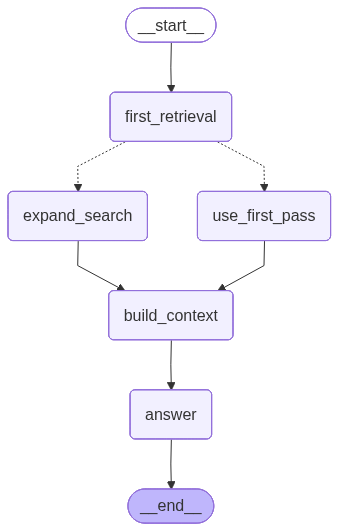

In [ ]:
from IPython.display import Image, display

display(
    Image(
        langgraph_rag.get_graph().draw_mermaid_png(
            max_retries=5,
            retry_delay=2.0,
        )
    )
)

In [ ]:
print(langgraph_rag.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	first_retrieval(first_retrieval)
	expand_search(expand_search)
	use_first_pass(use_first_pass)
	build_context(build_context)
	answer(answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> first_retrieval;
	build_context --> answer;
	expand_search --> build_context;
	first_retrieval -.-> expand_search;
	first_retrieval -.-> use_first_pass;
	use_first_pass --> build_context;
	answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [ ]:
question = sample_question

for chunk in langgraph_rag.stream(
    {"question": question},
    stream_mode="updates",
):
    print("=" * 100)
    print(chunk)

{'first_retrieval': {'first_pass_titles': ['The Duchess and the Jeweller', 'Index Magazine', 'British Journal', 'The Mark on the Wall', 'Orlando: A Biography'], 'need_expand': True}}
{'expand_search': {'final_titles': ['Index Magazine', 'British Journal', 'The Duchess and the Jeweller']}}
{'build_context': {'context': '[Document 1: Index Magazine]\nindex Magazine was a prominent New York City based publication with in-depth interviews with prominent figures in art and culture.  It was created by Peter Halley and Bob Nickas in 1996, running until late 2005.  Covering the burgeoning Indie culture of the 1990s, index regularly employed such rising photographers as Juergen Teller, Terry Richardson, Wolfgang Tillmans, and Ryan McGinley, and featured interviews with figures including Björk, Brian Eno, Marc Jacobs, and Scarlett Johansson, mixing new talents and established names in music, film, architecture, fashion, art, and politics.  In addition to famous personalities, the publication als

In [ ]:
for chunk in langgraph_rag.stream(
    {"question": sample_question},
    stream_mode="updates",
):
    print("=" * 100)
    for node_name, update in chunk.items():
        print(f"Node: {node_name}")
        for key, value in update.items():
            if isinstance(value, str) and len(value) > 400:
                value = value[:400] + " ..."
            print(f"  {key}: {value}")
    print()

Node: first_retrieval
  first_pass_titles: ['The Duchess and the Jeweller', 'Index Magazine', 'British Journal', 'The Mark on the Wall', 'Orlando: A Biography']
  need_expand: True

Node: expand_search
  final_titles: ['Index Magazine', 'British Journal', 'The Duchess and the Jeweller']

Node: build_context
  context: [Document 1: Index Magazine]
index Magazine was a prominent New York City based publication with in-depth interviews with prominent figures in art and culture.  It was created by Peter Halley and Bob Nickas in 1996, running until late 2005.  Covering the burgeoning Indie culture of the 1990s, index regularly employed such rising photographers as Juergen Teller, Terry Richardson, Wolfgang Tillmans, ...

Node: answer
  answer: The provided context does not contain any information about "Arthur's Magazine" or "First for Women." Therefore, it is not possible to determine which magazine was started first based on the given documents.



Поищем кандидатов лучше?

In [ ]:
def build_eval_lookup(eval_items):
    return {item["id"]: item for item in eval_items}

eval_lookup = build_eval_lookup(eval_items)

def select_demo_candidates(
    eval_items,
    qrels,
    hybrid_rankings,
    graph_rankings,
    topk=5,
    max_answer_words=6,
):
    rows = []

    for item in eval_items:
        qid = item["id"]
        question = item["question"]
        answer = str(item.get("answer", "")).strip()
        relevant = qrels[qid]

        # пропускаем yes/no и пустые ответы
        if answer.lower() in {"yes", "no", ""}:
            continue

        # хотим короткие, наглядные factoid-ответы
        if len(answer.split()) > max_answer_words:
            continue

        h_hits = count_hits(hybrid_rankings[qid], relevant, k=topk)
        g_hits = count_hits(graph_rankings[qid], relevant, k=topk)

        # оставляем только те случаи, где хотя бы один retriever
        # уже нашёл все релевантные документы
        if max(h_hits, g_hits) < len(relevant):
            continue

        rows.append({
            "qid": qid,
            "question": question,
            "answer": answer,
            "n_relevant": len(relevant),
            "hybrid_hits@5": h_hits,
            "graph_hits@5": g_hits,
            "support_docs": sorted(relevant),
        })

    return pd.DataFrame(rows).sort_values(
        by=["graph_hits@5", "hybrid_hits@5", "n_relevant"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

demo_candidates = select_demo_candidates(
    eval_items,
    qrels,
    hybrid_rankings,
    graph_rankings,
    topk=5,
    max_answer_words=6,
)

In [ ]:
best_qid = demo_candidates.iloc[0]["qid"]
best_question = demo_candidates.iloc[0]["question"]
gold_answer = demo_candidates.iloc[0]["answer"]

print("Question:", best_question)
print("Gold answer:", gold_answer)

langgraph_out = langgraph_rag.invoke({"question": best_question})

print("\nRetrieved titles:", langgraph_out["final_titles"])
print("\nAnswer:")
print(langgraph_out["answer"])

Question: What screenwriter with credits for "Evolution" co-wrote a film starring Nicolas Cage and Téa Leoni?
Gold answer: David Weissman

Retrieved titles: ['David Weissman', 'The Family Man', 'Drive Angry', 'Deadfall (1993 film)', 'David Ayer']

Answer:
The screenwriter with credits for "Evolution" who co-wrote a film starring Nicolas Cage and Téa Leoni is David Weissman. 

This is supported by:
- Document 1: David Weissman is a screenwriter and director with film credits including "The Family Man" (2000) and "Evolution" (2001).
- Document 2: "The Family Man" (2000) was written by David Diamond and David Weissman and stars Nicolas Cage and Téa Leoni.

Thus, David Weissman is the correct answer.


### `smolagents` vs `LangGraph`

Хотя обе реализации относятся к agentic-RAG, они отвечают на разные инженерные потребности.

| Подход | Что задаём явно | Где больше гибкости | Когда удобнее |
|---|---|---|---|
| `smolagents` | список инструментов и инструкцию | в выборе действий самим агентом | быстрый прототип, эксперименты с tool-using RAG |
| `LangGraph` | узлы, переходы и состояние | в проектировании самого workflow | контролируемый многошаговый retrieval, воспроизводимые пайплайны |

Главная идея здесь такая:

- если нужно **быстро проверить**, будет ли агент полезнее обычного RAG, удобно начать со `smolagents`;
- если уже понятно, что retrieval должен идти в несколько явных шагов, удобнее строить пайплайн в `LangGraph`.

На практике эти подходы не конкурируют напрямую: они закрывают разные уровни абстракции.

## Итоговые наблюдения

После расширения семинарской тетрадки можно выделить три уровня развития RAG-систем:

**1. Retrieval как один шаг пайплайна**
- dense retrieval;
- hybrid retrieval;
- оценка retriever'а через IR-метрики.

**2. Retrieval как многошаговый процесс**
- graph-aware retrieval;
- multi-hop сценарии;
- управление качеством поиска через повторные шаги.

**3. Retrieval как часть агентной или production-системы**
- `smolagents` для быстрого agentic-RAG;
- `LangGraph` для явного workflow и состояния.

Таким образом, RAG удобно рассматривать не как одну фиксированную архитектуру, а как целый класс систем, где можно отдельно улучшать:
- retrieval;
- orchestration;
- inference backend.